# Exercise 1 - Michaelis-Menten applications 

***a)*** we wish to determine the mass balance for the following chemical reaction. 

$$
E + S \xrightleftharpoons[k_b]{k_f} ES \xrightarrow{k_{cat}} E + P
$$

where:

- $S$ = substrate
- $E$ = free enzyme
- $ES$ = enzyme-substrate complex
- $P$ = product

***1. Species balances (mass balances)***

The reaction occurs in a **constant-volume batch reactor**.

Let the reactor volume be $V$, and let $N_i$ be the number of moles of species $i$.

For a batch reactor:

$$
\frac{dN_i}{dt} = \text{generation of } i
$$

Since volume is constant,

$$
N_i = C_i V
$$

and therefore

$$
\frac{dN_i}{dt} = V \frac{dC_i}{dt}
$$

So the mole balances become concentration balances:

$$
\frac{dC_i}{dt} = r_i
$$

where $r_i$ is the net rate of formation of species $i$.

***2. Elementary reaction rates***

Forward binding:

$$
r_f = k_f [E] [S]
$$

Reverse dissociation:

$$
r_b = k_b [ES]
$$

Catalytic product formation:

$$
r_{cat} = k_{cat} [ES]
$$

***3. Mass balances in concentration form***

*Substrate $S$*

Substrate is consumed when it binds enzyme and regenerated when $ES$ dissociates:

$$
\frac{d[S]}{dt} = -k_f C_E C_S + k_b [ES]
$$

*Free enzyme $E$*

Free enzyme is consumed in binding and regenerated in both dissociation and catalysis:

$$
\frac{d[E]}{dt} = -k_f C_E C_S + k_b [ES] + k_{cat} [ES]
$$


*Complex $ES$*

The complex is formed by binding and consumed by dissociation and catalysis:

$$
\frac{d[ES]}{dt} = k_f C_E C_S - k_b [ES] - k_{cat} [ES]
$$

or

$$
\frac{d[ES]}{dt} = k_f C_E C_S - (k_b + k_{cat}) [ES]
$$


*Product $P$*

Product is formed only through the catalytic step:

$$
\frac{d[P]}{dt} = k_{cat} [ES]
$$

***b)***

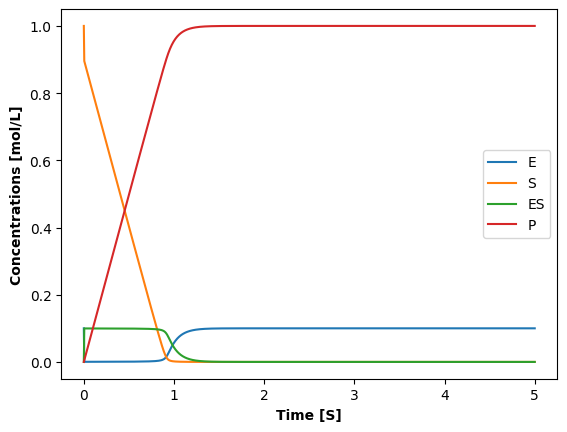

In [1]:
import numpy as np
from scipy.integrate import odeint
from matplotlib import pyplot as plt 

def equations(variables,t):
    E, S, ES, P = variables
    kb = 20 #s-1
    kf = 10000 #L/mol.s
    kcat = 10 #s-1
    dE_dt = kb * ES - kf * E * S + kcat * ES
    dS_dt = kb * ES - kf * E * S
    dES_dt = kf * E * S - kb * ES - kcat * ES
    dP_dt = kcat * ES
    return dE_dt, dS_dt, dES_dt, dP_dt

E0 = 0.1 #mol/L
S0 = 1 #mol/L
ES0 = P0 =  0 #mol/L
initial_conditions = [E0, S0, ES0, P0]

t=np.linspace(start=0, stop=5, num=1000)

results = odeint(equations, initial_conditions, t)

E, S, ES, P = results.T
plt.plot(t, E, t, S, t, ES, t, P)
plt.xlabel("Time [S]", fontweight = "bold")
plt.ylabel("Concentrations [mol/L]", fontweight = "bold")
plt.legend(["E", "S", "ES", "P"])
plt.show()


***Time evolution of the species***

At the beginning of the reaction, only free enzyme and substrate are present. Because substrate is in large excess relative to enzyme, the forward binding step is favored initially, so the enzyme rapidly associates with substrate to form the enzyme–substrate complex $ES$.

As a result:

- $ES$ rises quickly from zero  
- free enzyme $E$ drops to a very low value  
- substrate $S$ begins to decrease  
- product $P$ begins to form from zero  

This early behavior indicates that the enzyme is rapidly captured into the enzyme–substrate complex.

***Intermediate stage***

After the short initial transient, the concentration of $ES$ remains nearly constant for a period, while free enzyme $E$ also stays approximately constant at a low level. This is consistent with a **quasi-steady regime** in which the rate of complex formation is approximately balanced by the rates of complex breakdown through dissociation and product formation.

During this interval:

- $S$ decreases almost linearly  
- $P$ increases almost linearly  
- $ES$ is roughly constant  
- $E$ remains low and nearly constant  

The near-linear decrease of substrate and increase of product indicate that the reaction rate is approximately constant over this time range. Since most of the enzyme is tied up as $ES$, the catalytic conversion of substrate to product proceeds efficiently.

***Late stage***

As substrate becomes depleted, the forward binding rate

$$
k_f E S
$$

decreases because it depends on $S$. Once $S$ becomes very small, the enzyme–substrate complex can no longer be sustained.

Consequently:

- $ES$ falls toward zero  
- free enzyme $E$ rises back toward its total enzyme concentration  
- $S$ approaches zero  
- $P$ approaches its final maximum value  

At long times, essentially all substrate has been converted into product, so the system approaches its final state:

$$
S \rightarrow 0
$$

$$
ES \rightarrow 0
$$

$$
E \rightarrow E_0
$$

$$
P \rightarrow S_0
$$

This final behavior is consistent with **conservation of enzyme** and **conversion of substrate into product**.

***c)***
A common approximation in Michaelis–Menten kinetics is the **Quasi-Steady-State Approximation (QSSA)**, where the concentration of the enzyme-substrate complex $[ES]$ is assumed to be approximately time-invariant for a given substrate concentration $[S]$.

Thus,

$$
\frac{d[ES]}{dt} \approx 0
$$

From the mass balance on the complex,

$$
\frac{d[ES]}{dt} = k_f [E][S] - k_b [ES] - k_{cat}[ES]
$$

Setting this equal to zero under QSSA gives

$$
0 = k_f [E][S] - (k_b + k_{cat})[ES]
$$

The total enzyme concentration is conserved:

$$
[E_0] = [E] + [ES]
$$

so that

$$
[E] = [E_0] - [ES]
$$

Substituting this into the QSSA expression:

$$
0 = k_f ([E_0] - [ES])[S] - (k_b + k_{cat})[ES]
$$

Expanding:

$$
0 = k_f [E_0][S] - k_f [ES][S] - (k_b + k_{cat})[ES]
$$

Rearranging:

$$
k_f [E_0][S] = [ES]\left(k_f [S] + k_b + k_{cat}\right)
$$

Therefore, the expression for the enzyme-substrate complex is

$$
[ES] = \frac{k_f [E_0][S]}{k_f [S] + k_b + k_{cat}}
$$

***d)***

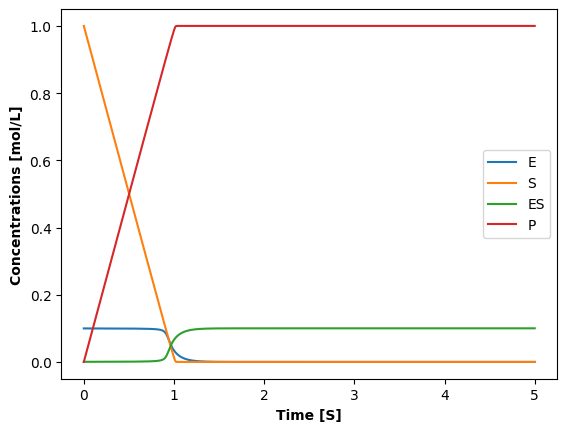

In [4]:
import numpy as np
from scipy.integrate import odeint
from matplotlib import pyplot as plt 


def equations_QSSA(variables,t):
    S, P = variables
    kb = 20 #s-1
    kf = 10000 #L/mol.s
    kcat = 10 #s-1
    ES = (kf * E0 * S)/(kcat+ kb + S * kf)
    E = E0 - ES
    dS_dt = kb * ES - kf * E * S
    dP_dt = kcat * ES
    return dS_dt, dP_dt

E0 = 0.1 #mol/L
S0 = 1 #mol/L
P0 =  0 #mol/L
initial_conditions = [S0, P0]

kb = 20 #s-1
kf = 10000 #L/mol.s
kcat = 10 #s-1
ES = (kf * E0 * S)/(kcat+ kb + S * kf)
E = E0 - ES

t=np.linspace(start=0, stop=5, num=1000)

results_QSSA = odeint(equations_QSSA, initial_conditions, t)

S, P = results_QSSA.T
plt.plot(t, ES, t, S, t, E, t, P)
plt.xlabel("Time [S]", fontweight = "bold")
plt.ylabel("Concentrations [mol/L]", fontweight = "bold")
plt.legend(["E", "S", "ES", "P"])
plt.show()


***Comparison between the full kinetic model and the QSSA model***

The product concentration obtained from the QSSA model was compared with the product concentration obtained from the full non–steady-state kinetic model shown in the figure above. In both cases, the simulations were performed over the time interval $[0,5]$ s using the same initial conditions and parameter values.

From the comparison plot, the two curves follow nearly identical trajectories over most of the simulation time. In both models, the product concentration $P$ increases rapidly from zero and approaches a final value close to $1 \ \mathrm{mol/L}$. This corresponds to the almost complete conversion of the initial substrate concentration into product.

The main difference between the two models appears during the very early stage of the reaction. In the full kinetic model, the enzyme–substrate complex $ES$ forms dynamically according to the elementary reaction steps. As a result, there is a short transient period during which the concentration of $ES$ increases before reaching its quasi-steady level. During this short buildup phase, the rate of product formation is slightly lower because not all enzyme molecules are immediately bound to substrate.

In contrast, the QSSA model assumes that the enzyme–substrate complex reaches its quasi-steady value instantaneously. This means that the intermediate dynamics of $ES$ are not explicitly resolved, and the reaction rate is directly governed by the steady-state expression for $ES$. Consequently, the QSSA prediction for the product concentration shows a slightly faster increase at the very beginning of the reaction.

However, once the transient period has passed and the concentration of $ES$ has stabilized, both models predict essentially the same reaction dynamics. After approximately the first fraction of a second, the two product concentration curves overlap almost perfectly. This indicates that the quasi-steady-state assumption captures the dominant kinetics of the system very accurately.

The good agreement between the two models can also be explained by the ratio between the initial substrate and enzyme concentrations. In this system, the substrate concentration ($S_0 = 1$ mol/L) is much larger than the enzyme concentration ($E_0 = 0.1$ mol/L). Under these conditions, the enzyme rapidly forms the enzyme–substrate complex and operates close to a steady catalytic cycle. Therefore, the concentration of $ES$ quickly reaches a nearly constant value, which validates the quasi-steady-state assumption.

Overall, the comparison demonstrates that the QSSA provides an excellent approximation of the full enzyme kinetics model for the given parameter values. The reduced QSSA model successfully reproduces the product formation dynamics while significantly simplifying the mathematical description of the system.

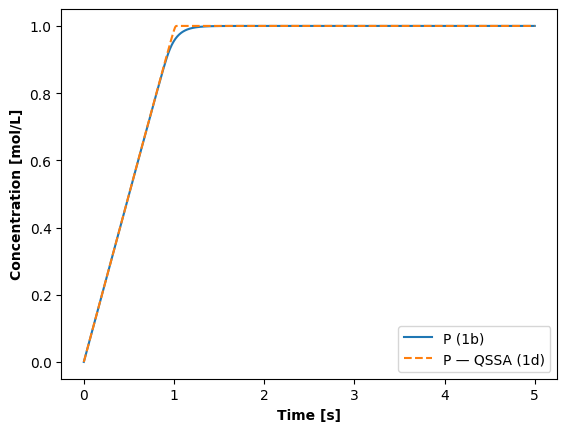

In [5]:
import numpy as np
from scipy.integrate import odeint
from matplotlib import pyplot as plt 

def equations(variables,t):
    E, S, ES, P = variables
    kb = 20 #s-1
    kf = 10000 #L/mol.s
    kcat = 10 #s-1
    dE_dt = kb * ES - kf * E * S + kcat * ES
    dS_dt = kb * ES - kf * E * S
    dES_dt = kf * E * S - kb * ES - kcat * ES
    dP_dt = kcat * ES
    return dE_dt, dS_dt, dES_dt, dP_dt

E0 = 0.1 #mol/L
S0 = 1 #mol/L
ES0 = P0 =  0 #mol/L
initial_conditions = [E0, S0, ES0, P0]

t=np.linspace(start=0, stop=5, num=1000)

results = odeint(equations, initial_conditions, t)

E, S, ES, P = results.T


def equations_QSSA(variables,t):
    S, P = variables
    kb = 20 #s-1
    kf = 10000 #L/mol.s
    kcat = 10 #s-1
    ES = (kf * E0 * S)/(kcat+ kb + S * kf)
    E = E0 - ES
    dS_dt = kb * ES - kf * E * S
    dP_dt = kcat * ES
    return dS_dt, dP_dt

E0 = 0.1 #mol/L
S0 = 1 #mol/L
P0 =  0 #mol/L
initial_conditions = [S0, P0]


t=np.linspace(start=0, stop=5, num=1000)

results_QSSA = odeint(equations_QSSA, initial_conditions, t)
P_QSSA = results_QSSA.T[1]

plt.plot(t, P, label="P (1b)")
plt.plot(t, P_QSSA, label="P — QSSA (1d)", linestyle="--")
plt.xlabel("Time [s]", fontweight="bold")
plt.ylabel("Concentration [mol/L]", fontweight="bold")
plt.legend()
plt.show()

The figure compares the product concentration $P(t)$ obtained from the full kinetic model with the product concentration predicted using the Quasi-Steady-State Approximation (QSSA). Both curves show a rapid increase in product concentration from $0$ to approximately $1 \ \mathrm{mol/L}$ within about $1$ s, after which the concentration remains constant due to substrate depletion.

The two curves overlap almost completely over the entire time interval $[0,5]$ s. A small difference can be observed at very early times, where the QSSA prediction increases slightly faster than the full model. This occurs because the full model accounts for the short transient buildup of the enzyme–substrate complex, whereas the QSSA assumes that the complex reaches its steady value instantaneously.

Overall, the close agreement between the two curves shows that the QSSA provides an accurate approximation of the full kinetic model for the given parameters and initial conditions.

***e)***

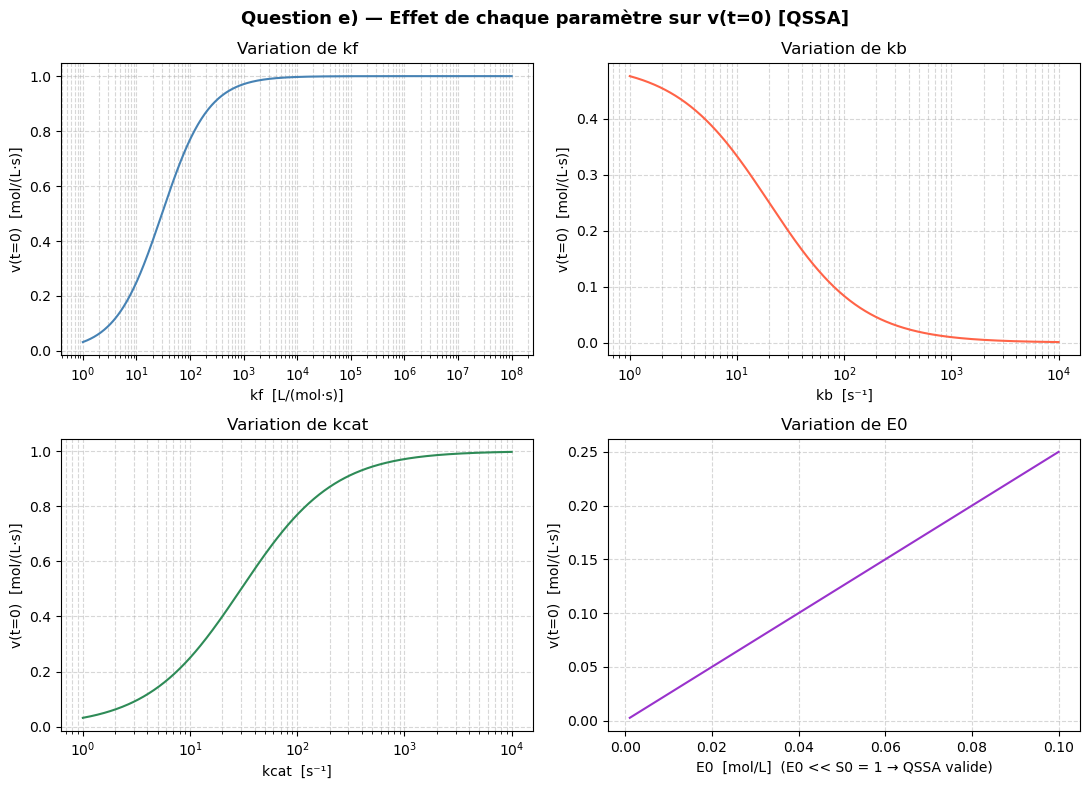

In [8]:
"""
Exercise 1e - Michaelis-Menten: effet des paramètres sur v(t=0)
sous l'hypothèse QSSA
"""

import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# PARAMÈTRES DE RÉFÉRENCE (valeurs fixes quand on ne les varie pas)
# =============================================================
S0       = 1.0   # mol/L  - concentration initiale en substrat
E0_ref   = 0.1   # mol/L  - concentration initiale en enzyme (référence)
kf_ref   = 10    # L/(mol·s)
kb_ref   = 20    # s⁻¹
kcat_ref = 10    # s⁻¹

# =============================================================
# FONCTION UTILITAIRE : calcule Km puis v(t=0) selon MM-QSSA
# =============================================================
def reaction_rate(kf, kb, kcat, E0, S):
    """
    Km  = (kb + kcat) / kf        [définition de la constante de Michaelis]
    v   = kcat * E0 * S / (Km + S) [équation de Michaelis-Menten]
    """
    Km = (kb + kcat) / kf
    v  = kcat * E0 * S / (Km + S)
    return v

# =============================================================
# PLAGES DE VARIATION  (logspace = espacement logarithmique,
# utile quand la plage couvre plusieurs ordres de grandeur)
# =============================================================
kf_range   = np.logspace(0, 8, 500)   # de 10^0=1  à 10^8  L/(mol·s)
kb_range   = np.logspace(0, 4, 500)   # de 10^0=1 à 10^4  s⁻¹
kcat_range = np.logspace(0, 4, 500)   # de 10^0=1 à 10^4  s⁻¹

# Pour E0 : la QSSA est valide uniquement si E0 << S0
# On choisit donc E0 entre 0.001 et 0.1 mol/L (toujours << S0=1)
E0_range = np.linspace(0.001, 0.1, 500)

# =============================================================
# CALCUL DE v(t=0) EN FAISANT VARIER UN PARAMÈTRE À LA FOIS
# (les autres restent à leur valeur de référence)
# =============================================================
v_kf   = reaction_rate(kf_range,   kb_ref,   kcat_ref, E0_ref, S0)
v_kb   = reaction_rate(kf_ref,     kb_range, kcat_ref, E0_ref, S0)
v_kcat = reaction_rate(kf_ref,     kb_ref,   kcat_range, E0_ref, S0)
v_E0   = reaction_rate(kf_ref,     kb_ref,   kcat_ref, E0_range, S0)

# =============================================================
# TRACÉ DES 4 GRAPHIQUES
# =============================================================
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle("Question e) — Effet de chaque paramètre sur v(t=0) [QSSA]",
             fontsize=13, fontweight='bold')

# --- kf ---
axes[0, 0].semilogx(kf_range, v_kf, color='steelblue')
axes[0, 0].set_xlabel("kf  [L/(mol·s)]")
axes[0, 0].set_ylabel("v(t=0)  [mol/(L·s)]")
axes[0, 0].set_title("Variation de kf")
axes[0, 0].grid(True, which='both', linestyle='--', alpha=0.5)

# --- kb ---
axes[0, 1].semilogx(kb_range, v_kb, color='tomato')
axes[0, 1].set_xlabel("kb  [s⁻¹]")
axes[0, 1].set_ylabel("v(t=0)  [mol/(L·s)]")
axes[0, 1].set_title("Variation de kb")
axes[0, 1].grid(True, which='both', linestyle='--', alpha=0.5)

# --- kcat ---
axes[1, 0].semilogx(kcat_range, v_kcat, color='seagreen')
axes[1, 0].set_xlabel("kcat  [s⁻¹]")
axes[1, 0].set_ylabel("v(t=0)  [mol/(L·s)]")
axes[1, 0].set_title("Variation de kcat")
axes[1, 0].grid(True, which='both', linestyle='--', alpha=0.5)

# --- E0 ---
axes[1, 1].plot(E0_range, v_E0, color='darkorchid')
axes[1, 1].set_xlabel("E0  [mol/L]  (E0 << S0 = 1 → QSSA valide)")
axes[1, 1].set_ylabel("v(t=0)  [mol/(L·s)]")
axes[1, 1].set_title("Variation de E0")
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

***Effect of kinetic parameters on the initial reaction rate***

Using the Michaelis–Menten expression

$$
v = \frac{v_{max}S}{K_M + S}
$$

with 

$$
v_{max} = k_{cat}E_0, \qquad K_M = \frac{k_b + k_{cat}}{k_f}
$$

the effect of the kinetic parameters $k_f$, $k_b$, $k_{cat}$ and the enzyme concentration $E_0$ on the initial reaction rate $v(t=0)$ was analyzed.

***Effect of $k_f$***

From the plot of $v$ vs $k_f$, the reaction rate increases rapidly at small values of $k_f$ and then approaches a plateau. This occurs because increasing $k_f$ decreases the Michaelis constant

$$
K_M = \frac{k_b + k_{cat}}{k_f}
$$

which increases the enzyme affinity for the substrate. As $k_f$ becomes very large, $K_M$ becomes small compared to $S$, and the reaction approaches the maximum rate $v_{max}$. Beyond this point, further increases in $k_f$ have little effect on the rate.

***Effect of $k_b$***

The plot of $v$ vs $k_b$ shows a slight decrease in the reaction rate as $k_b$ increases. A larger $k_b$ means the enzyme–substrate complex dissociates more easily back into enzyme and substrate instead of forming product. This increases $K_M$ and reduces the effective catalytic efficiency, leading to a small decrease in the initial reaction rate.

***Effect of $k_{cat}$***

The reaction rate increases linearly with $k_{cat}$. This is expected because the maximum reaction rate is directly proportional to $k_{cat}$ through

$$
v_{max} = k_{cat}E_0
$$

Therefore, increasing $k_{cat}$ directly increases the catalytic turnover of the enzyme and results in a higher initial reaction rate.

***Effect of $E_0$***

The plot of $v$ vs $E_0$ shows a linear increase in the reaction rate with increasing enzyme concentration. Since

$$
v_{max} = k_{cat}E_0
$$

the reaction rate scales directly with the amount of enzyme available to catalyze the reaction. The range of $E_0$ considered satisfies the QSSA assumption ($E_0 \ll S_0$), ensuring that the Michaelis–Menten approximation remains valid.

***Summary***

Overall, the initial reaction rate increases with $k_f$, $k_{cat}$ and $E_0$, while it slightly decreases with increasing $k_b$. Among these parameters, $k_{cat}$ and $E_0$ have the strongest influence because they directly control the maximum catalytic rate of the enzyme.

***f)***

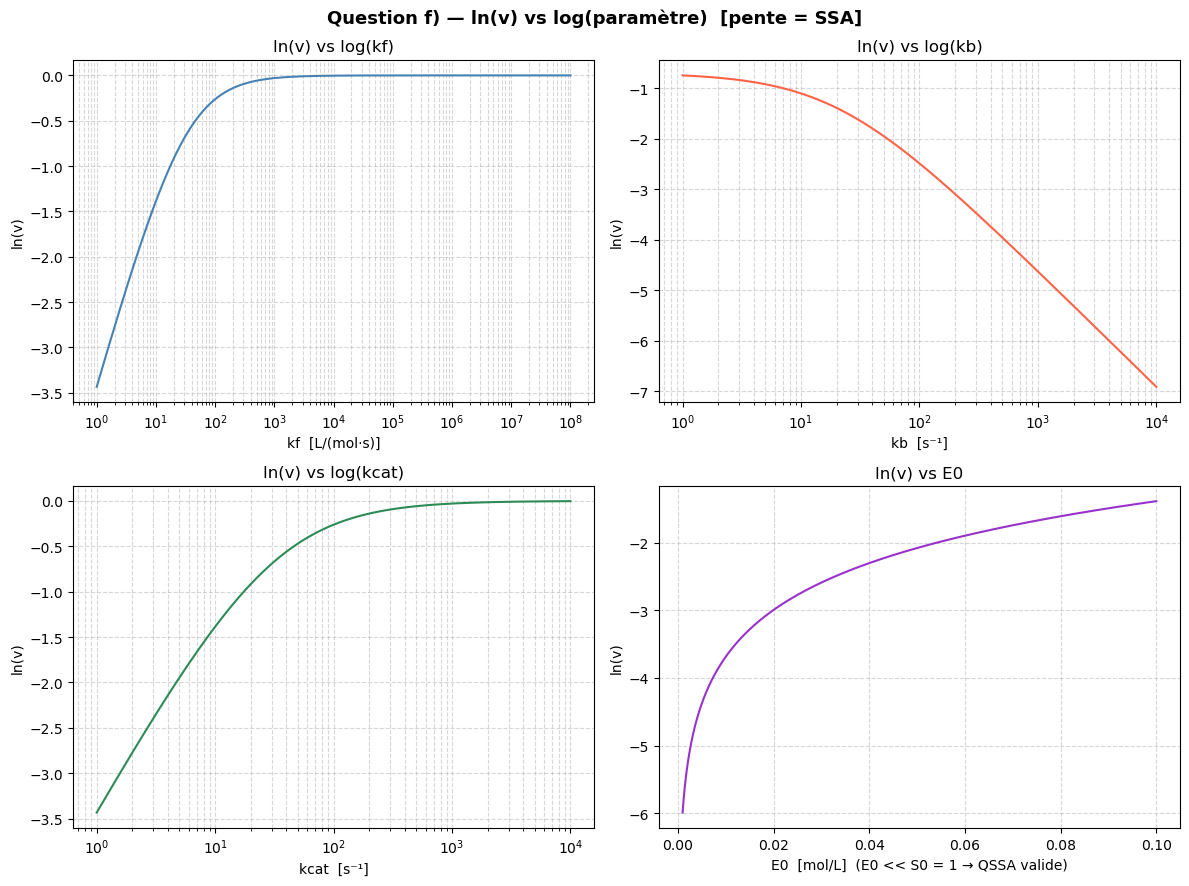

In [9]:
"""
Exercise 1f - Scaled Sensitivity Analysis (SSA)
On trace ln(v) vs log(paramètre) pour chaque paramètre.
La pente de cette courbe = SSA = d(ln v) / d(ln p)
Un paramètre important aura une pente élevée (en valeur absolue).
"""

import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# PARAMÈTRES DE RÉFÉRENCE
# =============================================================
S0       = 1.0   # mol/L
E0_ref   = 0.1   # mol/L
kf_ref   = 10    # L/(mol·s)
kb_ref   = 20    # s⁻¹
kcat_ref = 10    # s⁻¹

# =============================================================
# FONCTION : calcule v selon MM-QSSA
# =============================================================
def reaction_rate(kf, kb, kcat, E0, S):
    Km = (kb + kcat) / kf
    v  = kcat * E0 * S / (Km + S)
    return v

# =============================================================
# PLAGES DE VARIATION
# =============================================================
kf_range   = np.logspace(0, 8, 500)          # 1 → 10^8  L/(mol·s)
kb_range   = np.logspace(0, 4, 500)          # 1 → 10^4  s⁻¹
kcat_range = np.logspace(0, 4, 500)          # 1 → 10^4  s⁻¹
E0_range   = np.logspace(-3, -1, 500)    # E0 << S0 → QSSA valide

# =============================================================
# CALCUL DE v pour chaque plage (les autres params sont fixes)
# =============================================================
v_kf   = reaction_rate(kf_range,   kb_ref,   kcat_ref, E0_ref,   S0)
v_kb   = reaction_rate(kf_ref,     kb_range, kcat_ref, E0_ref,   S0)
v_kcat = reaction_rate(kf_ref,     kb_ref,   kcat_range, E0_ref, S0)
v_E0   = reaction_rate(kf_ref,     kb_ref,   kcat_ref, E0_range, S0)

# =============================================================
# TRACÉ : ln(v) vs log(paramètre)
# La pente = SSA = d(ln v) / d(ln p)
# =============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Question f) — ln(v) vs log(paramètre)  [pente = SSA]",
             fontsize=13, fontweight='bold')

# --- kf ---
axes[0, 0].semilogx(kf_range, np.log(v_kf), color='steelblue')
axes[0, 0].set_xlabel("kf  [L/(mol·s)]")
axes[0, 0].set_ylabel("ln(v)")
axes[0, 0].set_title("ln(v) vs log(kf)")
axes[0, 0].grid(True, which='both', linestyle='--', alpha=0.5)

# --- kb ---
axes[0, 1].semilogx(kb_range, np.log(v_kb), color='tomato')
axes[0, 1].set_xlabel("kb  [s⁻¹]")
axes[0, 1].set_ylabel("ln(v)")
axes[0, 1].set_title("ln(v) vs log(kb)")
axes[0, 1].grid(True, which='both', linestyle='--', alpha=0.5)

# --- kcat ---
axes[1, 0].semilogx(kcat_range, np.log(v_kcat), color='seagreen')
axes[1, 0].set_xlabel("kcat  [s⁻¹]")
axes[1, 0].set_ylabel("ln(v)")
axes[1, 0].set_title("ln(v) vs log(kcat)")
axes[1, 0].grid(True, which='both', linestyle='--', alpha=0.5)

# --- E0 ---
axes[1, 1].plot(E0_range, np.log(v_E0), color='darkorchid')
axes[1, 1].set_xlabel("E0  [mol/L]  (E0 << S0 = 1 → QSSA valide)")
axes[1, 1].set_ylabel("ln(v)")
axes[1, 1].set_title("ln(v) vs E0")
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

***Scaled sensitivity analysis of the initial reaction rate***

To identify the most important parameters affecting the initial reaction rate $v$, a scaled sensitivity analysis was performed by plotting $\ln v$ versus the logarithm of each parameter. The slope of these curves indicates how sensitive the reaction rate is to changes in the corresponding parameter.

*Sensitivity to $k_f$*

The plot of $\ln v$ vs $\ln k_f$ shows that the sensitivity decreases as $k_f$ increases. For small values of $k_f$, the slope is close to 1, meaning that the reaction rate is strongly dependent on $k_f$. However, as $k_f$ becomes larger, the slope approaches zero, indicating that further increases in $k_f$ have little effect on the reaction rate. This occurs because at large $k_f$ values the enzyme–substrate complex forms rapidly and the reaction rate becomes limited by the catalytic step rather than by substrate binding.

*Sensitivity to $k_b$*

The sensitivity of $v$ with respect to $k_b$ is very small and slightly negative, as seen from the nearly flat curve close to zero. This indicates that changes in $k_b$ have only a minor effect on the initial reaction rate. Increasing $k_b$ slightly decreases $v$ because a larger dissociation rate reduces the stability of the enzyme–substrate complex.

*Sensitivity to $k_{cat}$*

The plot of $\ln v$ vs $\ln k_{cat}$ shows a slope close to 1 across the range considered. This indicates that the initial reaction rate is strongly and approximately linearly dependent on $k_{cat}$. Since the maximum reaction rate is given by

$$
v_{max} = k_{cat}E_0
$$

an increase in $k_{cat}$ directly increases the catalytic turnover of the enzyme and therefore significantly increases the reaction rate.

*Conclusion*

The scaled sensitivity analysis shows that the most important parameter controlling the initial reaction rate is $k_{cat}$, followed by $k_f$ at low values. The parameter $k_b$ has only a very small influence on the rate. Therefore, the catalytic rate constant $k_{cat}$ is the dominant factor determining the reaction velocity under the given conditions.

***g)***

## g) Mass balance and concentration balance for the branched enzyme mechanism

We consider the reaction scheme

$$
E + S \xrightleftharpoons[k_b]{k_f} ES
$$

$$
ES \xrightarrow{k_{cat1}} E + P
$$

$$
ES \xrightarrow{k_{cat2}} E + P'
$$

where $S$ is the substrate, $E$ is the free enzyme, $ES$ is the enzyme–substrate complex, and $P$ and $P'$ are two different products.

*Step 1: Reaction rates*

The elementary rates are

$$
r_f = k_f [E][S]
$$

$$
r_b = k_b [ES]
$$

$$
r_{cat1} = k_{cat1}[ES]
$$

$$
r_{cat2} = k_{cat2}[ES]
$$

*Step 2: Mass balances*

For a constant-volume batch reactor, the mole balance on each species is

$$
\frac{dN_i}{dt} = \text{rate of formation of species } i
$$

Thus, the balances are:

*Substrate $S$*

Substrate is consumed in the forward binding step and regenerated in the reverse step:

$$
\frac{dN_S}{dt} = -k_f [E][S]V + k_b [ES]V
$$

*Free enzyme $E$*

Free enzyme is consumed when forming the complex and regenerated by complex dissociation and both catalytic pathways:

$$
\frac{dN_E}{dt} = -k_f [E][S]V + k_b [ES]V + k_{cat1}[ES]V + k_{cat2}[ES]V
$$

*Complex $ES$*

The complex is formed by enzyme–substrate association and consumed by dissociation and both catalytic reactions:

$$
\frac{dN_{ES}}{dt} = k_f [E][S]V - k_b [ES]V - k_{cat1}[ES]V - k_{cat2}[ES]V
$$

*Product $P$*

Product $P$ is formed only through the first catalytic pathway:

$$
\frac{dN_P}{dt} = k_{cat1}[ES]V
$$

*Product $P'$*

Product $P'$ is formed only through the second catalytic pathway:

$$
\frac{dN_{P'}}{dt} = k_{cat2}[ES]V
$$

*Step 3: Simplification to concentration balances*

Since the reactor volume is constant,

$$
N_i = [i]V
$$

and therefore

$$
\frac{dN_i}{dt} = V\frac{d[i]}{dt}
$$

Dividing each mass balance by $V$ gives the concentration balances:

$$
\frac{d[S]}{dt} = -k_f [E][S] + k_b [ES]
$$

*Free enzyme balance*

$$
\frac{d[E]}{dt} = -k_f [E][S] + k_b [ES] + k_{cat1}[ES] + k_{cat2}[ES]
$$

*Complex balance*

$$
\frac{d[ES]}{dt} = k_f [E][S] - k_b [ES] - k_{cat1}[ES] - k_{cat2}[ES]
$$

or equivalently,

$$
\frac{d[ES]}{dt} = k_f [E][S] - (k_b + k_{cat1} + k_{cat2})[ES]
$$

*Product balances*

$$
\frac{d[P]}{dt} = k_{cat1}[ES]
$$

$$
\frac{d[P']}{dt} = k_{cat2}[ES]
$$

*Step 4: Enzyme conservation*

Because the enzyme is either free or bound in the complex, the total enzyme concentration is conserved:

$$
[E]_0 = [E] + [ES]
$$

*Final system of concentration balances*

$$
\frac{d[S]}{dt} = -k_f [E][S] + k_b [ES]
$$

$$
\frac{d[E]}{dt} = -k_f [E][S] + (k_b + k_{cat1} + k_{cat2})[ES]
$$

$$
\frac{d[ES]}{dt} = k_f [E][S] - (k_b + k_{cat1} + k_{cat2})[ES]
$$

$$
\frac{d[P]}{dt} = k_{cat1}[ES]
$$

$$
\frac{d[P']}{dt} = k_{cat2}[ES]
$$

with

$$
[E]_0 = [E] + [ES]
$$

This is the full concentration-balance model for the branched reaction network, without applying the QSSA.

***h)***

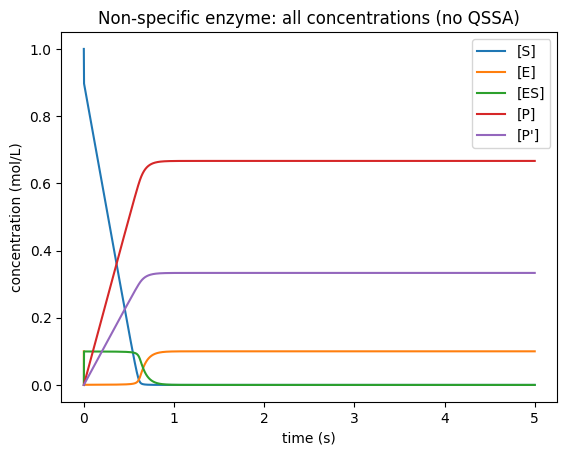

In [8]:
kf =1e4
kb=20.0
kcat1=10
kcat2=5.0

S0=1.0
E0=0.1
ES0=0.0
P0=0.0
Pp0=0.0

def equations(variables,t):
    S,E,ES,P,Pp=variables
    dS=-kf*S*E+kb*ES
    dE=-kf*E*S+kb*ES+kcat1*ES+kcat2*ES
    dES=-kcat2*ES-kcat1*ES+kf*E*S-kb*ES
    dP=kcat1*ES
    dPp=kcat2*ES


    return dS,dE,dES,dP,dPp

initial_conditions =[S0,E0,ES0,P0,Pp0]
t=np.linspace(start=0,stop=5,num=2001)

results=odeint(equations,initial_conditions,t)
S,E,ES,P,Pp=results.T

plt.figure()
plt.plot(t, S,  label='[S]')
plt.plot(t, E,  label='[E]')
plt.plot(t, ES, label='[ES]')
plt.plot(t, P,  label='[P]')
plt.plot(t, Pp, label="[P']")
plt.xlabel('time (s)')
plt.ylabel('concentration (mol/L)')
plt.title('Non-specific enzyme: all concentrations (no QSSA)')
plt.legend()
plt.show()

***i)***

The two products $P$ and $P'$ are formed from the same intermediate complex $ES$ through two competing catalytic pathways:

$$
ES \xrightarrow{k_{cat1}} E + P
$$

$$
ES \xrightarrow{k_{cat2}} E + P'
$$

Therefore, the selectivity between the two products is determined by the relative values of the catalytic rate constants $k_{cat1}$ and $k_{cat2}$. The selectivity toward $P$ can be approximated as

$$
S_P \approx \frac{k_{cat1}}{k_{cat2}}
$$

To increase the selectivity toward product $P$, one should increase $k_{cat1}$ or decrease $k_{cat2}$. Increasing $k_{cat1}$ enhances the rate at which the complex $ES$ is converted into $P$, while decreasing $k_{cat2}$ reduces the competing pathway that produces $P'$.

The binding parameters $k_f$ and $k_b$ primarily control the formation and dissociation of the enzyme–substrate complex and therefore affect the overall reaction rate, but they do not significantly change the selectivity between the two products.

Thus, the most effective way to increase selectivity toward $P$ is to increase the ratio $k_{cat1}/k_{cat2}$.

# Exercise 2 - Monod Kinetics

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### Plots of Biomass concentration X(t) and sunbstrate concentration S(t)

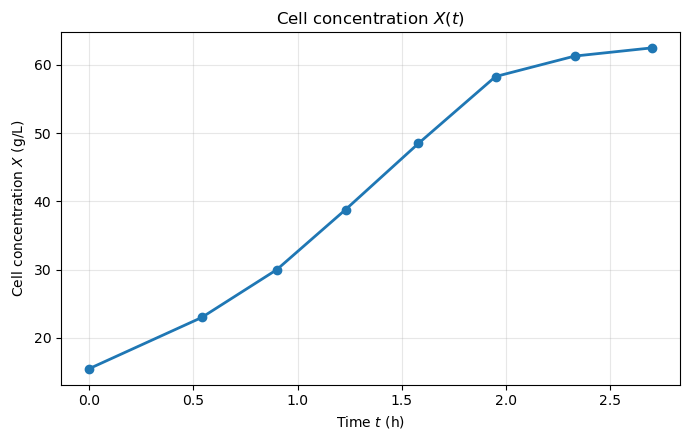

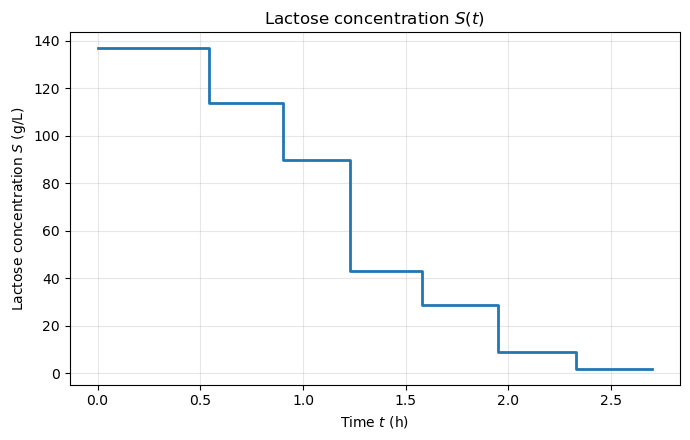

In [2]:
t_start = np.array([0.00, 0.54, 0.90, 1.23, 1.58, 1.95, 2.33])
t_end   = np.array([0.54, 0.90, 1.23, 1.58, 1.95, 2.33, 2.70])

X_start = np.array([15.5, 23.0, 30.0, 38.8, 48.5, 58.3, 61.3])
X_end   = np.array([23.0, 30.0, 38.8, 48.5, 58.3, 61.3, 62.5])

S_const = np.array([137.0, 114.0, 90.0, 43.0, 29.0, 9.0, 2.0])
S = S_const

t_X = np.concatenate(([t_start[0]], t_end))
X_t = np.concatenate(([X_start[0]], X_end))

t_S = np.ravel(np.column_stack([t_start, t_end]))
S_t = np.ravel(np.column_stack([S_const, S_const]))

plt.figure(figsize=(7,4.5))
plt.plot(t_X, X_t, marker="o", linewidth=2)
plt.xlabel("Time $t$ (h)")
plt.ylabel("Cell concentration $X$ (g/L)")
plt.title("Cell concentration $X(t)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("X_vs_time.png", dpi=300)
plt.show()

plt.figure(figsize=(7,4.5))
plt.step(t_S, S_t, where="post", linewidth=2)
plt.xlabel("Time $t$ (h)")
plt.ylabel("Lactose concentration $S$ (g/L)")
plt.title("Lactose concentration $S(t)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("S_vs_time.png", dpi=300)
plt.show()

The evolution of the X(t) curve during the batch culture shows the expected phases of microbial kinetics. In fact, we can see that at the beginning of the experiment (around 0-0.5h), the biomass concentration increases slowly. This is the **lag phase**; cells are adapting to the new environment and are synthesizing the enzymes necessary for lactose metabolism, so their growth is still limited. Then, between 0.5h and 1.9h, the cell concentration increases a lot quicker, almost exponentially, this is the **exponential phase** of microbial kinetics. Here, cells are diving at a constant specific growth rate and substrate concentration is still high, meaning that our growth conditions are optimal. Finally, after 1.9h, the slope decreases considerably. This is the **stationary phase** of microbial kinetics, where the growth rate slows down as the lactose concentration becomes limiting.  

### Lineweaver-Burke type plot 


Interval |   S (g/L) |   mu (1/h)
       1 |    137.0 |    0.8961
       2 |    114.0 |    0.8454
       3 |     90.0 |    0.8889
       4 |     43.0 |    0.7143
       5 |     29.0 |    0.5461
       6 |      9.0 |    0.1354
       7 |      2.0 |    0.0529

--- Lineweaver–Burk Results ---
Used intervals: [2, 3, 4, 5]
mu_max = 1.13999 1/h
K_s    = 29.81615 g/L


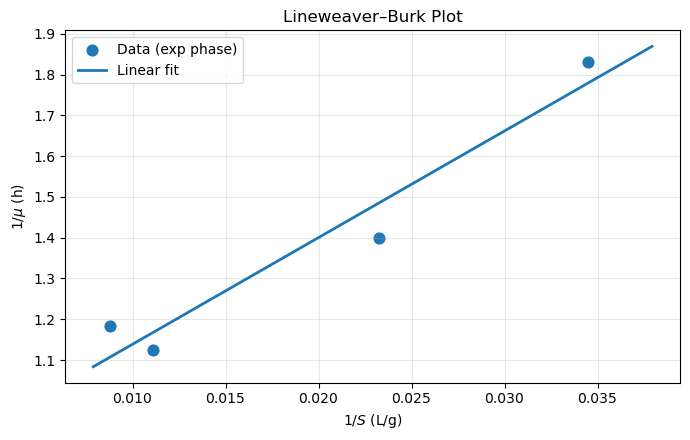

In [3]:
dt = t_end - t_start
dXdt = (X_end - X_start) / dt
mu = dXdt / X_start   

print("\nInterval |   S (g/L) |   mu (1/h)")
for i in range(len(S)):
    print(f"{i+1:>8} | {S[i]:>8.1f} | {mu[i]:>9.4f}")


exp_intervals = [2, 3, 4, 5]   
exp_idx = [k-1 for k in exp_intervals]

S_exp = S[exp_idx]
mu_exp = mu[exp_idx]


x = 1.0 / S_exp
y = 1.0 / mu_exp

m, b = np.polyfit(x, y, 1)

mu_max = 1.0 / b
K_s = m * mu_max

print("\n--- Lineweaver–Burk Results ---")
print(f"Used intervals: {exp_intervals}")
print(f"mu_max = {mu_max:.5f} 1/h")
print(f"K_s    = {K_s:.5f} g/L")


plt.figure(figsize=(7,4.5))
plt.scatter(x, y, s=60, label="Data (exp phase)")
x_line = np.linspace(min(x)*0.9, max(x)*1.1, 200)
plt.plot(x_line, m*x_line + b, linewidth=2, label="Linear fit")

plt.xlabel(r"$1/S$ (L/g)")
plt.ylabel(r"$1/\mu$ (h)")
plt.title("Lineweaver–Burk Plot")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("Lineweaver_Burk.png", dpi=300)
plt.show()

To estimate the Monod parameters, the specific growth rate $\mu$ was first calculated for each time interval using the relation

$$
\mu = \frac{1}{X_{min}}\frac{dX}{dt}
$$

where $X$ is the biomass concentration. The derivative $\frac{dX}{dt}$ was approximated using finite differences between the measured biomass concentrations at the beginning and end of each interval.

Only the points corresponding to the exponential growth phase were used for this plot, since Monod kinetics applies when cells are actively growing and the lag and stationary phases should be neglected. Based on the biomass curve, intervals 2–5 (0.5h-1.9h) were selected.

A Lineweaver–Burk type plot was then constructed by plotting $\frac{1}{\mu}$ versus $\frac{1}{S}$. According to the linearized Monod equation

$$
\frac{1}{\mu} = \frac{K_s}{\mu_{max}}\frac{1}{S} + \frac{1}{\mu_{max}}
$$

the slope corresponds to $\frac{K_s}{\mu_{max}}$ and the intercept corresponds to $\frac{1}{\mu_{max}}$.

From the linear regression of the selected points, the following parameters were obtained:

- $\mu_{max} \approx 1.14\ \text{h}^{-1}$
- $K_s \approx 29.8\ \text{g L}^{-1}$

The value of $\mu_{max}$ represents the maximum possible specific growth rate at very high substrate concentrations, which explains why it can be slightly larger than the individual $\mu$ values measured during the experiment.

### Mass doubling time 

The mass doubling time $t_d$ is the time required fot the mass of the cell to double during the exponential growth phase. During exponential growth, the biomass follows

$$
\frac{dX}{dt} = \mu X
$$

where $X$ is the biomass concentration and $\mu$ is the specific growth rate.

Solving this differential equation gives the exponential growth law

$$
X(t) = X_0 e^{\mu t}
$$

where $X_0$ is the initial biomass concentration.

The doubling time corresponds to the time at which the biomass becomes twice the initial value:

$$
X(t_d) = 2X_0
$$

Substituting into the exponential equation:

$$
2X_0 = X_0 e^{\mu t_d}
$$

Dividing by $X_0$:

$$
2 = e^{\mu t_d}
$$

Taking the natural logarithm:

$$
\ln 2 = \mu t_d
$$

which gives the expression

$$
t_d = \frac{\ln 2}{\mu}
$$

To estimate the doubling time, we assume that the cells grow in the exponential phase, where the growth rate is approximately constant. In this region, the specific growth rate approaches the maximum specific growth rate obtained from the Lineweaver–Burk analysis:

$$
\mu_{max} \approx 1.14 \ \text{h}^{-1}
$$

Therefore,

$$
t_d = \frac{\ln 2}{1.14}
$$

$$
t_d \approx 0.61 \ \text{h}
$$

Thus, the biomass doubles approximately every 0.61 hours (about 37 minutes) during the exponential growth phase.

# Bonus 

We are given sucrose concentration measurements in a batch reactor and the initial enzyme concentration.  
We assume Michaelis–Menten kinetics with constant enzyme concentration.

Goal: estimate $K_M$ and $k_{cat}$ so that the model matches the measured $S(t)$.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

# Experimental data (t in hours, S in mmol/L)
t_exp = np.array([0.0, 2.0, 6.0, 10.0])
S_exp = np.array([1.0, 0.68, 0.16, 0.006])

# Given enzyme concentration
E0 = 0.01  # mmol/L

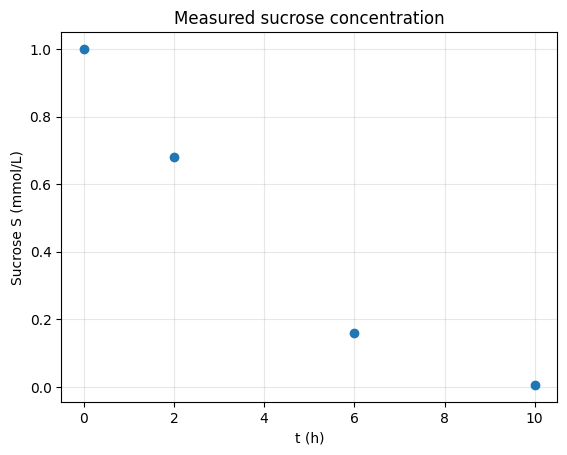

In [10]:
plt.figure()
plt.plot(t_exp, S_exp, "o")
plt.xlabel("t (h)")
plt.ylabel("Sucrose S (mmol/L)")
plt.title("Measured sucrose concentration")
plt.grid(True, alpha=0.3)
plt.show()

Michaelis–Menten rate:

$$
v = \frac{V_{max} S}{K_M + S}
$$

with

$$
V_{max} = k_{cat} E_0
$$

Batch substrate balance:

$$
\frac{dS}{dt} = -\frac{k_{cat} E_0 S}{K_M + S}
$$

In [11]:
def dSdt(t, S, KM, kcat):
    Vmax = kcat * E0  # mmol/L/h
    return -Vmax * S / (KM + S)

def simulate_S(KM, kcat, t_eval):
    sol = solve_ivp(
        fun=lambda t, y: dSdt(t, y[0], KM, kcat),
        t_span=(t_eval[0], t_eval[-1]),
        y0=[S_exp[0]],
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-12
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.y[0]

In [12]:
def residuals(theta):
    KM, kcat = theta
    S_sim = simulate_S(KM, kcat, t_exp)

    # Weighting so the small final point matters
    w = 1.0 / np.maximum(S_exp, 1e-3)
    return (S_sim - S_exp) * w

theta0 = np.array([0.1, 10.0])  # initial guess: KM (mmol/L), kcat (1/h)
bounds = ([1e-8, 1e-8], [1e3, 1e6])

res = least_squares(residuals, theta0, bounds=bounds)
KM_fit, kcat_fit = res.x

Vmax_fit = kcat_fit * E0

KM_fit, kcat_fit, Vmax_fit

(0.19662997795783177, 19.99981838956833, 0.1999981838956833)

KM   = 0.19663 mmol/L
kcat = 19.9998 1/h
Vmax = 0.199998 mmol/L/h

Model vs data:
t= 0.0 h | data=1 | model=1
t= 2.0 h | data=0.68 | model=0.676772
t= 6.0 h | data=0.16 | model=0.160158
t=10.0 h | data=0.006 | model=0.0059993


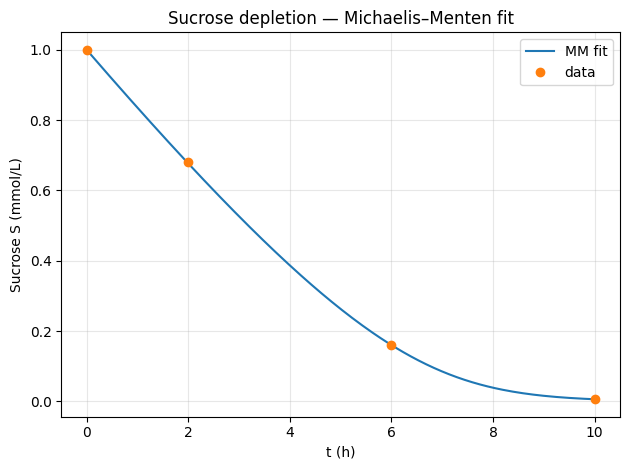

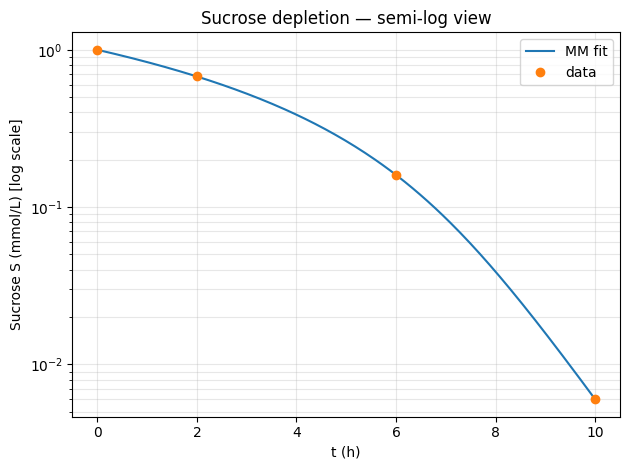

In [13]:
t_dense = np.linspace(0, 10, 200)
S_fit_dense = simulate_S(KM_fit, kcat_fit, t_dense)
S_fit_exp = simulate_S(KM_fit, kcat_fit, t_exp)

print(f"KM   = {KM_fit:.6g} mmol/L")
print(f"kcat = {kcat_fit:.6g} 1/h")
print(f"Vmax = {Vmax_fit:.6g} mmol/L/h")

print("\nModel vs data:")
for t, Sd, Sm in zip(t_exp, S_exp, S_fit_exp):
    print(f"t={t:>4.1f} h | data={Sd:.6g} | model={Sm:.6g}")

# Linear plot
plt.figure()
plt.plot(t_dense, S_fit_dense, label="MM fit")
plt.plot(t_exp, S_exp, "o", label="data")
plt.xlabel("t (h)")
plt.ylabel("Sucrose S (mmol/L)")
plt.title("Sucrose depletion — Michaelis–Menten fit")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("bonus_S_fit.png", dpi=200)
plt.show()

# Semi-log plot (helps show late-time behavior)
plt.figure()
plt.semilogy(t_dense, np.maximum(S_fit_dense, 1e-12), label="MM fit")
plt.semilogy(t_exp, np.maximum(S_exp, 1e-12), "o", label="data")
plt.xlabel("t (h)")
plt.ylabel("Sucrose S (mmol/L) [log scale]")
plt.title("Sucrose depletion — semi-log view")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("bonus_S_fit_semilog.png", dpi=200)
plt.show()

***Estimated kinetic parameters***

Fitting the batch Michaelis–Menten model

$$
\frac{dS}{dt} = -\frac{k_{cat} E_0 S}{K_M + S}
$$

to the measured sucrose concentration data gave:

•⁠  ⁠$K_M = 0.197 \ \mathrm{mmol\,L^{-1}}$
•⁠  ⁠$k_{cat} = 20.0 \ \mathrm{h^{-1}}$
•⁠  ⁠$V_{max} = k_{cat} E_0 = 0.200 \ \mathrm{mmol\,L^{-1}\,h^{-1}}$  
  (with $E_0 = 0.01 \ \mathrm{mmol\,L^{-1}}$)

The fitted model matches the measurements closely at all time points (linear and semi-log plots).

***Physical interpretation***

The estimated $K_M$ represents the substrate concentration at which the reaction rate equals half of $V_{max}$.

Here, the initial sucrose concentration is

$$
S_0 = 1 \ \mathrm{mmol\,L^{-1}}
$$

and since

$$
K_M \approx 0.20 \ \mathrm{mmol\,L^{-1}},
$$

we have $S_0 \approx 5K_M$.

This means the enzyme initially operates close to saturation, and the reaction rate is near $V_{max}$.

As sucrose is depleted and $S \ll K_M$, the kinetics approach first-order behavior in $S$:

$$
v \approx \frac{V_{max}}{K_M} S
$$

This explains the strong curvature observed in the semi-log plot at later times.